    QBER |    eta=1.0 |    eta=0.5 |    eta=0.1 | Analytical |   D(eta=1)
----------------------------------------------------------------------------
 0.0000 |   0.499998 |   0.249998 |   0.049998 |   0.500000 |   2.07e-06
 0.0024 |   0.475228 |   0.237613 |   0.047521 |   0.475230 |   2.06e-06
 0.0049 |   0.455364 |   0.227681 |   0.045535 |   0.455366 |   2.06e-06
 0.0073 |   0.437358 |   0.218678 |   0.043734 |   0.437360 |   2.06e-06
 0.0098 |   0.420561 |   0.210279 |   0.042054 |   0.420563 |   2.06e-06
 0.0122 |   0.404665 |   0.202332 |   0.040465 |   0.404667 |   2.06e-06
 0.0147 |   0.389490 |   0.194744 |   0.038947 |   0.389492 |   2.06e-06
 0.0171 |   0.374915 |   0.187456 |   0.037490 |   0.374917 |   2.06e-06
 0.0196 |   0.360855 |   0.180427 |   0.036084 |   0.360857 |   2.05e-06
 0.0220 |   0.347247 |   0.173623 |   0.034723 |   0.347249 |   2.10e-06
 0.0245 |   0.334041 |   0.167020 |   0.033402 |   0.334043 |   2.05e-06
 0.0269 |   0.321198 |   0.160598 |   0.032118

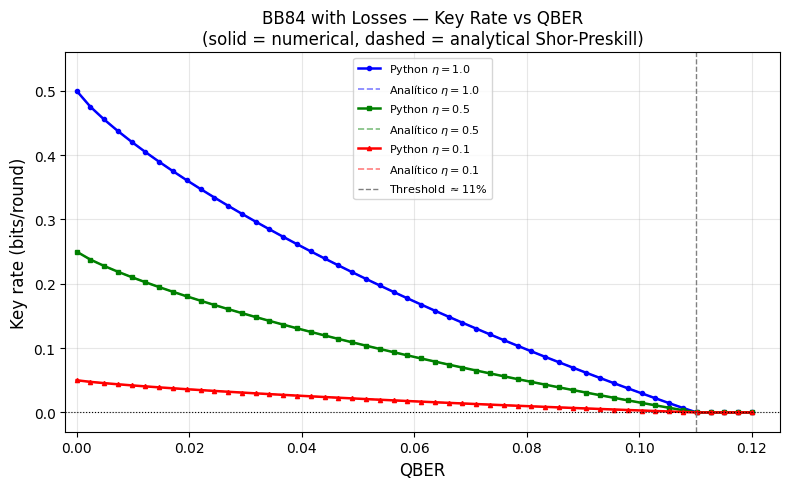

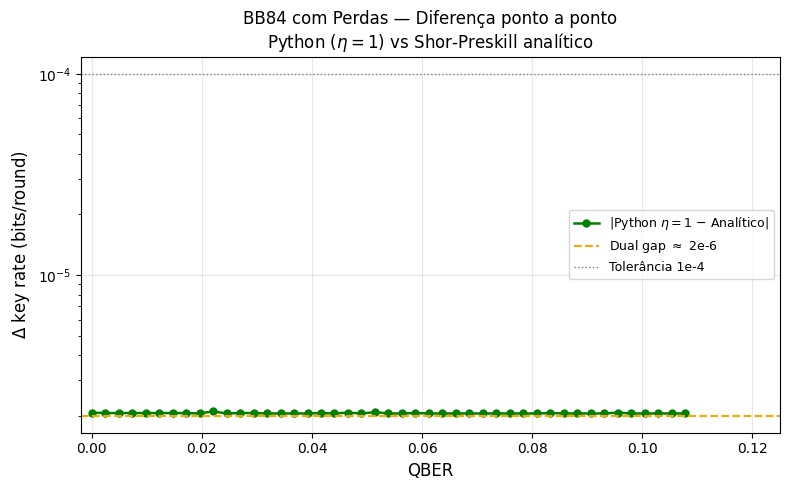


-> benchmark_loss_vs_qber.csv exportado
-> benchmark_loss_curves.png e benchmark_loss_delta.png exportados
-> Erro maximo (eta=1) vs analitico: 2.10e-06 OK


In [2]:
"""
Benchmark: key rate vs QBER for fixed η.
Produz: benchmark_loss_vs_qber.csv | benchmark_loss_curves.png | benchmark_loss_delta.png
"""

import sys, numpy as np, csv
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import matplotlib.pyplot as plt
from openqkd.presets.bb84_loss_preset import BasicBB84LossPreset
from openqkd.optimizer.main_iteration  import MainIteration


def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic_loss(qber, eta, pz=0.5):
    """Shor-Preskill with losses: r = η × sift × (1 − 2h(e))"""
    sift = pz**2 + (1 - pz)**2
    return max(0.0, eta * sift * (1 - 2 * h(qber)))


SCENARIOS = {"eta=1.0": 1.0, "eta=0.5": 0.5, "eta=0.1": 0.1}

PLOT_LABELS = {
    "eta=1.0": r"$\eta=1.0$",
    "eta=0.5": r"$\eta=0.5$",
    "eta=0.1": r"$\eta=0.1$",
}

STYLES = {
    "eta=1.0": ("b-o", "b"),
    "eta=0.5": ("g-s", "g"),
    "eta=0.1": ("r-^", "r"),
}

QBER_RANGE = np.linspace(0, 0.12, 50)
PZ = 0.5

# ── Table header ────────────────────────────────────────────────────
col = " | ".join(f"{lbl:>10}" for lbl in SCENARIOS)
print(f"{'QBER':>8} | {col} | {'Analytical':>10} | {'D(eta=1)':>10}")
print("-" * (8 + 3 + 13 * len(SCENARIOS) + 26))

rows = []
results = {lbl: [] for lbl in SCENARIOS}

for qber in QBER_RANGE:
    depol = 2.0 * qber
    an    = bb84_analytic_loss(float(qber), eta=1.0, pz=PZ)
    row   = {"qber": round(float(qber), 6), "analytic_eta1": round(an, 8)}
    line_vals = []

    for label, eta in SCENARIOS.items():
        r  = MainIteration(BasicBB84LossPreset(depolarization=depol, eta=eta, pz=PZ))
        kr = max(0.0, r["key_rate"])
        row[label] = round(kr, 8)
        results[label].append(kr)
        line_vals.append(f"{kr:>10.6f}")

    delta = abs(results["eta=1.0"][-1] - an)
    row["delta_eta1"] = round(delta, 8)
    rows.append(row)
    print(f" {qber:.4f} | {' | '.join(line_vals)} | {an:>10.6f} | {delta:>10.2e}")

# ── CSV ────────────────────────────────────────────────────────────────────
fieldnames = ["qber"] + list(SCENARIOS.keys()) + ["analytic_eta1", "delta_eta1"]
with open("benchmark_loss_vs_qber.csv", "w", newline="", encoding="utf-8-sig") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader(); w.writerows(rows)

# ── Plot 1: (numerical + analytical vs. η) ────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

for label, eta in SCENARIOS.items():
    num_style, color = STYLES[label]
    plot_label       = PLOT_LABELS[label]
    an_curve         = [bb84_analytic_loss(q, eta, PZ) for q in QBER_RANGE]

    ax1.plot(QBER_RANGE, results[label], num_style, ms=3, lw=1.8,
             label=f"Python {plot_label}")
    ax1.plot(QBER_RANGE, an_curve, "--", lw=1.2, color=color, alpha=0.5,
             label=f"Analítico {plot_label}")

ax1.axhline(0, color="k", ls=":", lw=0.8)
ax1.axvline(0.11, color="gray", ls="--", lw=1, label="Threshold $\\approx 11\\%$")
ax1.set_xlabel("QBER", fontsize=12)
ax1.set_ylabel("Key rate (bits/round)", fontsize=12)
ax1.set_title(
    "BB84 with Losses — Key Rate vs QBER\n"
    "(solid = numerical, dashed = analytical Shor-Preskill)",
    fontsize=12
)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_xlim(-0.002, 0.125); ax1.set_ylim(-0.03, 0.56)
plt.tight_layout()
plt.savefig("benchmark_loss_curves.png", dpi=150)
plt.show()

# ── Plot 2: |numerical − analytical| for η=1.0 (semilogy) ──────────────────
valid = [(r["qber"], r["delta_eta1"]) for r in rows if r["analytic_eta1"] > 0]
q_v, d_v = zip(*valid)

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.semilogy(q_v, d_v, "g-o", ms=5, lw=1.8,
             label=r"|Python $\eta=1$ $-$ Analítico|")
ax2.axhline(2e-6, color="orange", ls="--", lw=1.5, label="Dual gap $\\approx$ 2e-6")
ax2.axhline(1e-4, color="gray",   ls=":",  lw=1.0, label="Tolerância 1e-4")
ax2.set_xlabel("QBER", fontsize=12)
ax2.set_ylabel("$\\Delta$ key rate (bits/round)", fontsize=12)
ax2.set_title(
    "BB84 com Perdas — Diferença ponto a ponto\n"
    r"Python ($\eta=1$) vs Shor-Preskill analítico",
    fontsize=12
)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xlim(-0.002, 0.125)
plt.tight_layout()
plt.savefig("benchmark_loss_delta.png", dpi=150)
plt.show()

max_d = max(d_v)
print("\n-> benchmark_loss_vs_qber.csv exportado")
print("-> benchmark_loss_curves.png e benchmark_loss_delta.png exportados")
print(f"-> Erro maximo (eta=1) vs analitico: {max_d:.2e} {'OK' if max_d < 1e-4 else 'VERIFICAR'}")


    QBER |    eta=1.0 |    eta=0.5 |    eta=0.1 | Analytical |   D(eta=1)
----------------------------------------------------------------------------
 0.0000 |   0.499998 |   0.249998 |   0.049998 |   0.500000 |   2.07e-06
 0.0024 |   0.475228 |   0.237613 |   0.047521 |   0.475230 |   2.06e-06
 0.0049 |   0.455364 |   0.227681 |   0.045535 |   0.455366 |   2.06e-06
 0.0073 |   0.437358 |   0.218678 |   0.043734 |   0.437360 |   2.06e-06
 0.0098 |   0.420561 |   0.210279 |   0.042054 |   0.420563 |   2.06e-06
 0.0122 |   0.404665 |   0.202332 |   0.040465 |   0.404667 |   2.06e-06
 0.0147 |   0.389490 |   0.194744 |   0.038947 |   0.389492 |   2.06e-06
 0.0171 |   0.374915 |   0.187456 |   0.037490 |   0.374917 |   2.06e-06
 0.0196 |   0.360855 |   0.180427 |   0.036084 |   0.360857 |   2.05e-06
 0.0220 |   0.347247 |   0.173623 |   0.034723 |   0.347249 |   2.10e-06
 0.0245 |   0.334041 |   0.167020 |   0.033402 |   0.334043 |   2.05e-06
 0.0269 |   0.321198 |   0.160598 |   0.032118

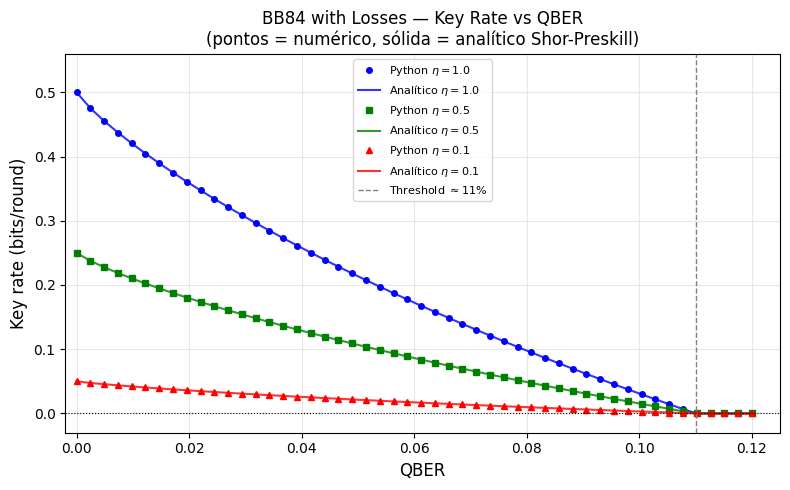

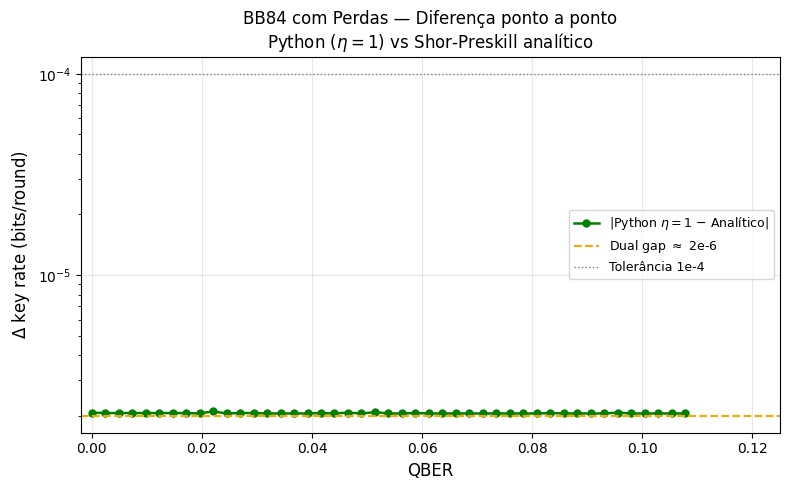


-> benchmark_loss_vs_qber.csv exportado
-> benchmark_loss_curves.png e benchmark_loss_delta.png exportados
-> Erro maximo (eta=1) vs analitico: 2.10e-06 OK


In [3]:
"""
Benchmark: key rate vs QBER for fixed η.
Produz: benchmark_loss_vs_qber.csv | benchmark_loss_curves.png | benchmark_loss_delta.png
"""

import sys, numpy as np, csv
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import matplotlib.pyplot as plt
from openqkd.presets.bb84_loss_preset import BasicBB84LossPreset
from openqkd.optimizer.main_iteration  import MainIteration


def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic_loss(qber, eta, pz=0.5):
    """Shor-Preskill with losses: r = η × sift × (1 − 2h(e))"""
    sift = pz**2 + (1 - pz)**2
    return max(0.0, eta * sift * (1 - 2 * h(qber)))


SCENARIOS = {"eta=1.0": 1.0, "eta=0.5": 0.5, "eta=0.1": 0.1}

PLOT_LABELS = {
    "eta=1.0": r"$\eta=1.0$",
    "eta=0.5": r"$\eta=0.5$",
    "eta=0.1": r"$\eta=0.1$",
}

STYLES = {
    "eta=1.0": ("b-o", "b"),
    "eta=0.5": ("g-s", "g"),
    "eta=0.1": ("r-^", "r"),
}

QBER_RANGE = np.linspace(0, 0.12, 50)
PZ = 0.5

# ── Table header ────────────────────────────────────────────────────
col = " | ".join(f"{lbl:>10}" for lbl in SCENARIOS)
print(f"{'QBER':>8} | {col} | {'Analytical':>10} | {'D(eta=1)':>10}")
print("-" * (8 + 3 + 13 * len(SCENARIOS) + 26))

rows = []
results = {lbl: [] for lbl in SCENARIOS}

for qber in QBER_RANGE:
    depol = 2.0 * qber
    an    = bb84_analytic_loss(float(qber), eta=1.0, pz=PZ)
    row   = {"qber": round(float(qber), 6), "analytic_eta1": round(an, 8)}
    line_vals = []

    for label, eta in SCENARIOS.items():
        r  = MainIteration(BasicBB84LossPreset(depolarization=depol, eta=eta, pz=PZ))
        kr = max(0.0, r["key_rate"])
        row[label] = round(kr, 8)
        results[label].append(kr)
        line_vals.append(f"{kr:>10.6f}")

    delta = abs(results["eta=1.0"][-1] - an)
    row["delta_eta1"] = round(delta, 8)
    rows.append(row)
    print(f" {qber:.4f} | {' | '.join(line_vals)} | {an:>10.6f} | {delta:>10.2e}")

# ── CSV ────────────────────────────────────────────────────────────────────
fieldnames = ["qber"] + list(SCENARIOS.keys()) + ["analytic_eta1", "delta_eta1"]
with open("benchmark_loss_vs_qber.csv", "w", newline="", encoding="utf-8-sig") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader(); w.writerows(rows)

# ── Plot 1: (apenas pontos numéricos + curva analítica sólida) ────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

for label, eta in SCENARIOS.items():
    num_style, color = STYLES[label]
    plot_label       = PLOT_LABELS[label]
    an_curve         = [bb84_analytic_loss(q, eta, PZ) for q in QBER_RANGE]

    # Marcadores apenas (sem linha) — extrai o símbolo do estilo original
    marker = num_style.replace("-", "").replace("b","").replace("g","").replace("r","")
    ax1.plot(QBER_RANGE, results[label], marker=marker, linestyle="None",  # ← só pontos
             ms=4, color=color, label=f"Python {plot_label}")

    ax1.plot(QBER_RANGE, an_curve, "-", lw=1.5, color=color, alpha=0.8,   # ← sólida
             label=f"Analítico {plot_label}")

ax1.axhline(0, color="k", ls=":", lw=0.8)
ax1.axvline(0.11, color="gray", ls="--", lw=1, label="Threshold $\\approx 11\\%$")
ax1.set_xlabel("QBER", fontsize=12)
ax1.set_ylabel("Key rate (bits/round)", fontsize=12)
ax1.set_title(
    "BB84 with Losses — Key Rate vs QBER\n"
    "(pontos = numérico, sólida = analítico Shor-Preskill)",
    fontsize=12
)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_xlim(-0.002, 0.125); ax1.set_ylim(-0.03, 0.56)
plt.tight_layout()
plt.savefig("benchmark_loss_curves.png", dpi=150)
plt.show()


# ── Plot 2: |numerical − analytical| for η=1.0 (semilogy) ──────────────────
valid = [(r["qber"], r["delta_eta1"]) for r in rows if r["analytic_eta1"] > 0]
q_v, d_v = zip(*valid)

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.semilogy(q_v, d_v, "g-o", ms=5, lw=1.8,
             label=r"|Python $\eta=1$ $-$ Analítico|")
ax2.axhline(2e-6, color="orange", ls="--", lw=1.5, label="Dual gap $\\approx$ 2e-6")
ax2.axhline(1e-4, color="gray",   ls=":",  lw=1.0, label="Tolerância 1e-4")
ax2.set_xlabel("QBER", fontsize=12)
ax2.set_ylabel("$\\Delta$ key rate (bits/round)", fontsize=12)
ax2.set_title(
    "BB84 com Perdas — Diferença ponto a ponto\n"
    r"Python ($\eta=1$) vs Shor-Preskill analítico",
    fontsize=12
)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xlim(-0.002, 0.125)
plt.tight_layout()
plt.savefig("benchmark_loss_delta.png", dpi=150)
plt.show()

max_d = max(d_v)
print("\n-> benchmark_loss_vs_qber.csv exportado")
print("-> benchmark_loss_curves.png e benchmark_loss_delta.png exportados")
print(f"-> Erro maximo (eta=1) vs analitico: {max_d:.2e} {'OK' if max_d < 1e-4 else 'VERIFICAR'}")
